<a href="https://colab.research.google.com/github/samer-glitch/TADP-Cluster-Computing/blob/main/Energy_Cost_CO2_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPERIMENT A — ENERGY / COST / CO2
Source: tables/K10_energy_cost_co2_runtime_mean_sd.csv
Results: 5-run means, K=10


,Scenario,Energy_Wh,Energy_Wh_SD,Cost_USD,Cost_USD_SD,CO2_kg,CO2_kg_SD
0,FedProx,5.883308,0.818036,0.001177,0.00016361,0.002795,0.000389
1,TADP-AA Federated,2.242822,0.786144,0.000449,0.00015723,0.001065,0.000373
2,Vanilla FedAvg,2.077947,0.798080,0.000416,0.00015962,0.000987,0.000379
3,Great Expectations Federated,1.894954,0.816301,0.000379,0.00016326,0.000900,0.000388
4,Random-K,1.069784,0.390100,0.000214,0.00007802,0.000508,0.000185
5,TADP-VR Federated,0.993326,0.400363,0.000199,0.00008007,0.000472,0.000190
6,TADP-SDA Federated,0.240054,0.081820,0.000048,0.00001636,0.000114,0.000039
7,Naïve Centralized,0.154970,0.010968,0.000031,0.00000219,0.000074,0.000005
8,TADP-AA Centralized,0.151241,0.007290,0.000030,0.00000146,0.000072,0.000003
9,Great Expectations Centralized,0.149906,0.017491,0.000030,0.00000350,0.000071,0.000008


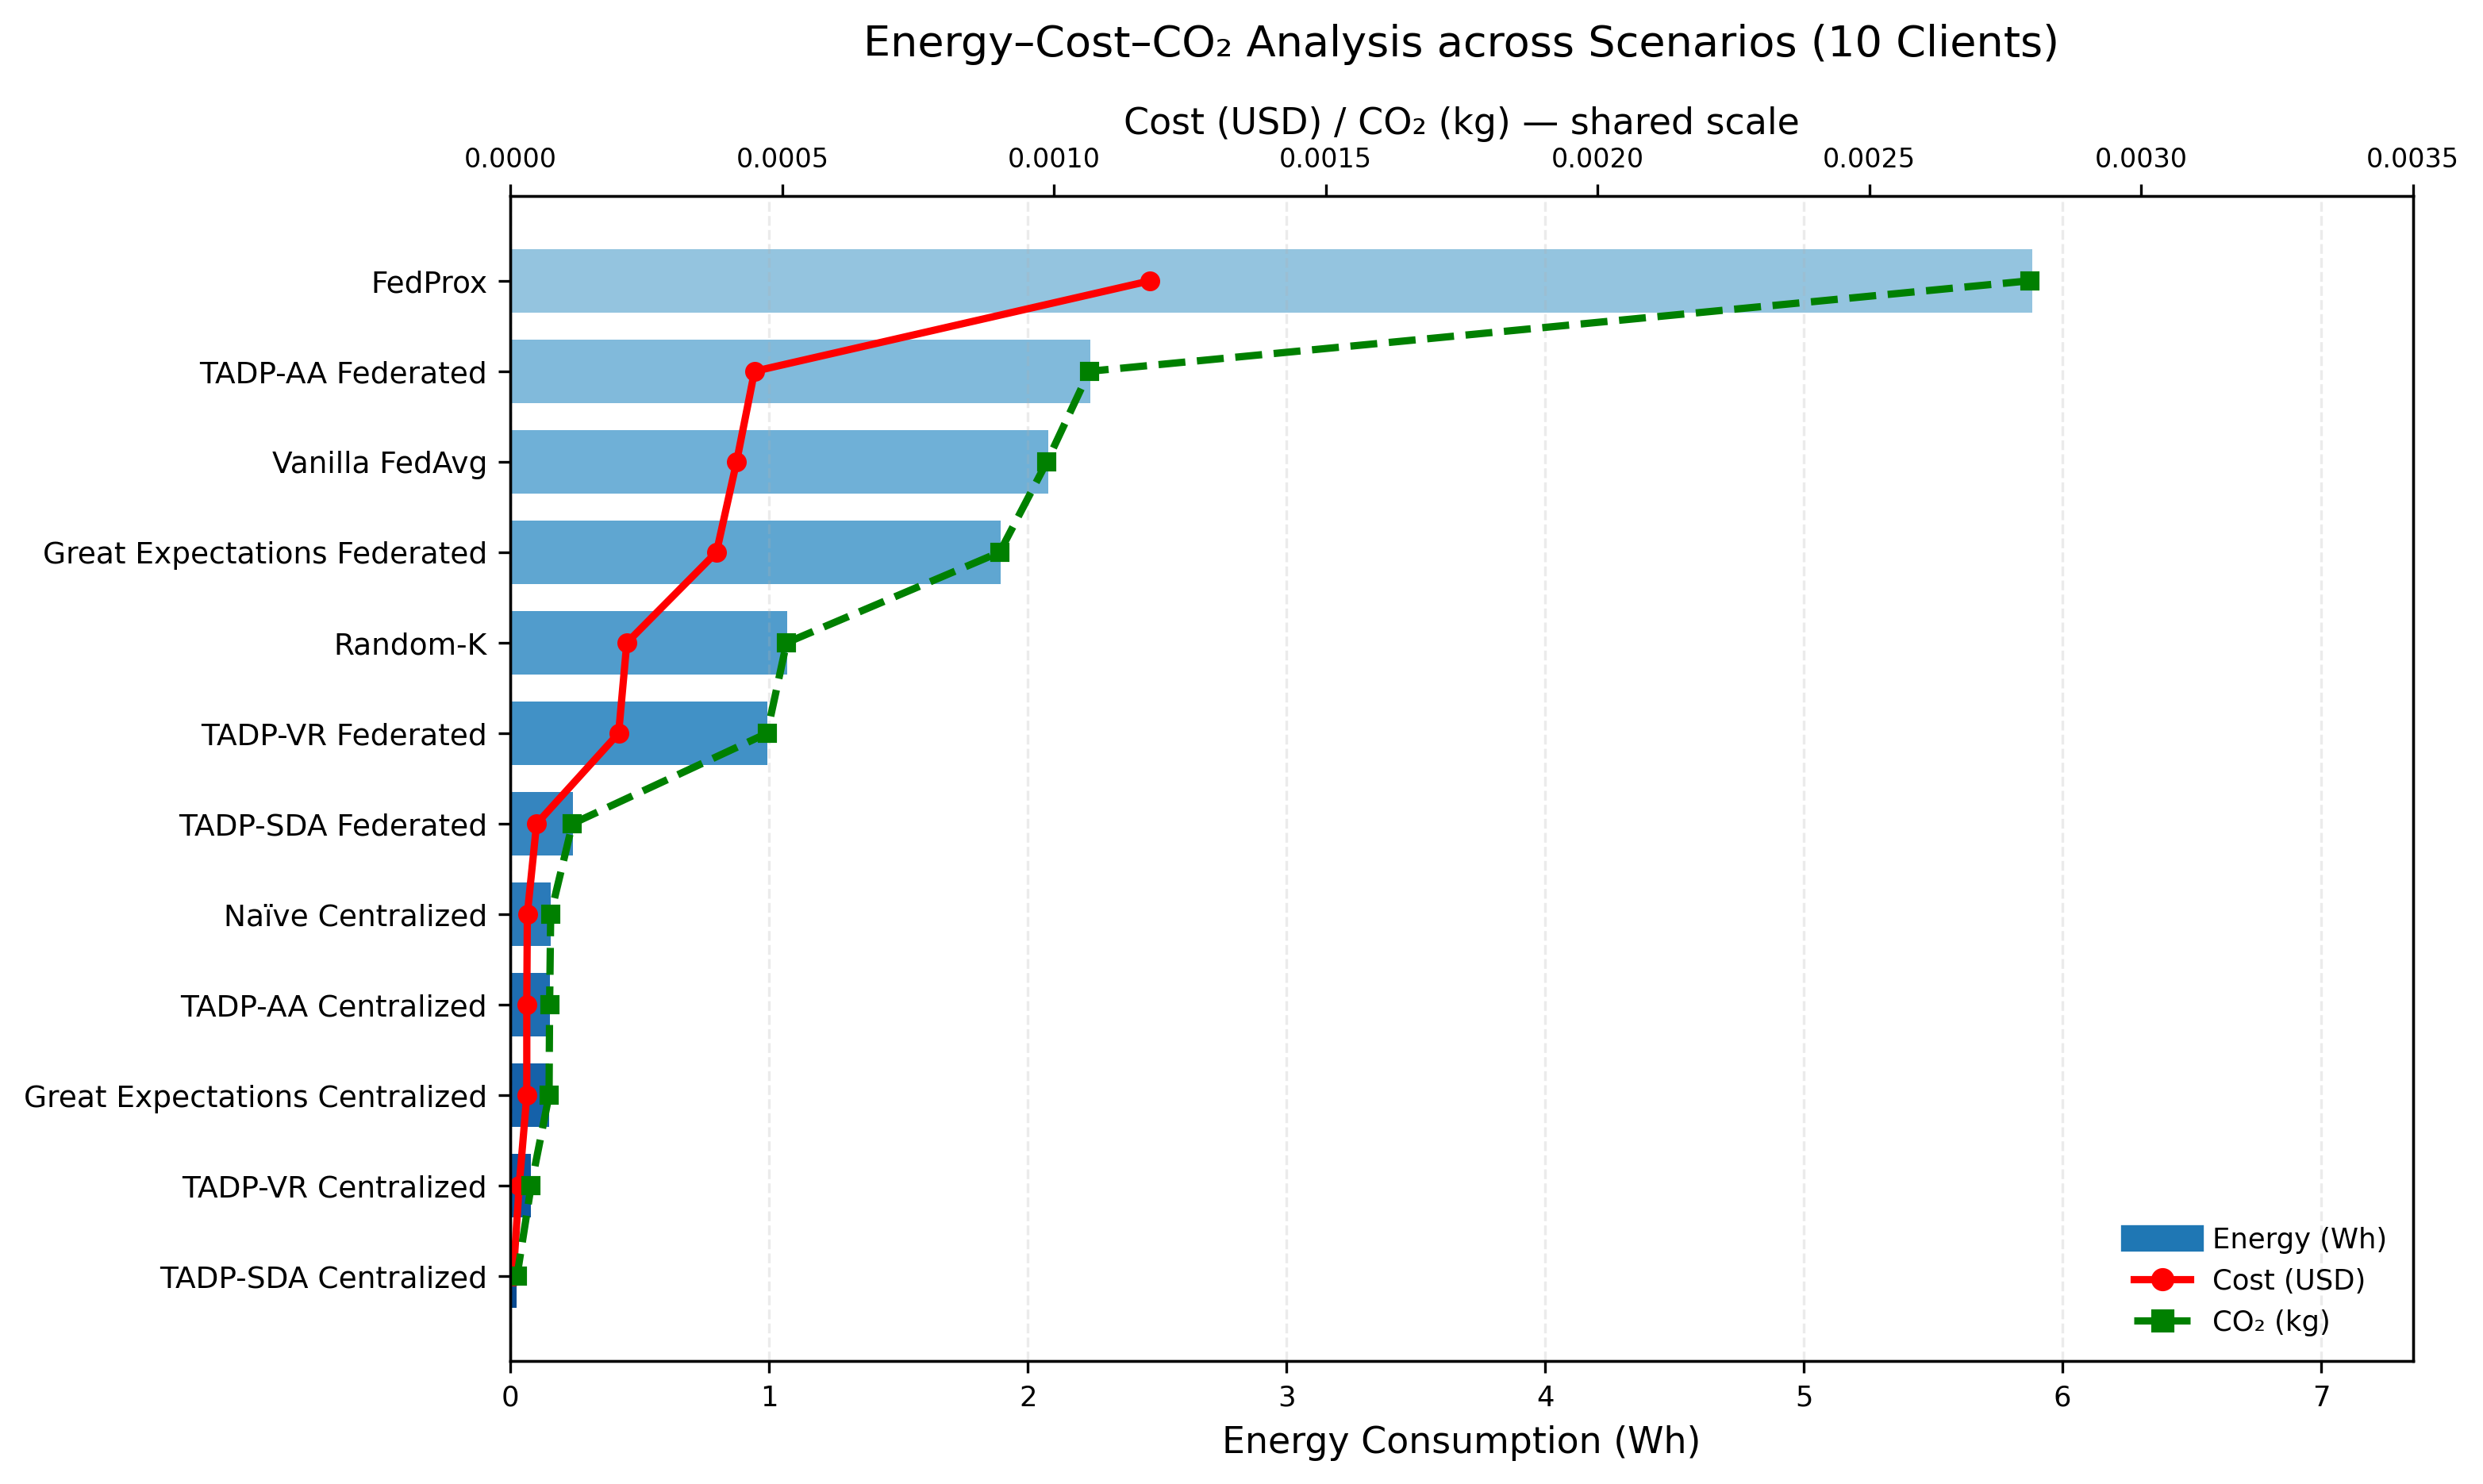


✅ FIGURE GENERATED FROM ATTACHED EXPERIMENT-A ZIP RESULTS
Internal ZIP source:
tables/K10_energy_cost_co2_runtime_mean_sd.csv

Highest energy:
   FedProx: 5.883308 Wh

Lowest energy:
   TADP-SDA Centralized: 0.025038 Wh

TADP-VR Federated:
   Energy = 0.993326 ± 0.400363 Wh
   Cost   = $0.000199
   CO₂    = 0.000472 kg

PNG saved: /content/ExperimentA_energy_cost_co2_K10_5run_means.png
PDF saved: /content/ExperimentA_energy_cost_co2_K10_5run_means.pdf
ZIP saved: /content/ExperimentA_energy_cost_co2_K10_5run_means.zip

⬇️ Triggering automatic browser download of the ZIP package...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# ======================================================================================
# EXPERIMENT A — ENERGY / COST / CO2 FIGURE
# EXACT VALUES RETRIEVED FROM:
# TADP_ExperimentA_K10_v9_FINAL_RESULTS_20260915_171600.zip
#
# Internal source:
# tables/K10_energy_cost_co2_runtime_mean_sd.csv
#
# Plot design intentionally follows the OLD manuscript figure:
#   • horizontal blue Energy bars
#   • red Cost line
#   • green dashed CO2 line
#   • Cost and CO2 share the top x-axis
#   • scenarios sorted by decreasing Energy
#
# Values below are the 5-run MEANS from Experiment A.
# SD values are retained in the dataframe for auditability,
# but are not plotted because the requested figure matches the old design.
#
# NEW:
#   • saves PNG and PDF
#   • creates one ZIP package
#   • automatically triggers download to your laptop in Colab
# ======================================================================================

import os
import math
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D


# ======================================================================================
# 1. ACTUAL EXPERIMENT-A RESULTS RETRIEVED FROM THE ATTACHED ZIP
# ======================================================================================

data = [

    ["FedProx", 5.883308, 0.818036, 0.001177, 0.0001636072, 0.002795, 0.000389],
    ["TADP-AA Federated", 2.242822, 0.786144, 0.000449, 0.0001572287, 0.001065, 0.000373],
    ["Vanilla FedAvg", 2.077947, 0.798080, 0.000416, 0.0001596160, 0.000987, 0.000379],
    ["Great Expectations Federated", 1.894954, 0.816301, 0.000379, 0.0001632602, 0.000900, 0.000388],
    ["Random-K", 1.069784, 0.390100, 0.000214, 0.0000780200, 0.000508, 0.000185],
    ["TADP-VR Federated", 0.993326, 0.400363, 0.000199, 0.00008007269, 0.000472, 0.000190],
    ["TADP-SDA Federated", 0.240054, 0.081820, 0.000048, 0.00001636391, 0.000114, 0.000039],
    ["Naïve Centralized", 0.154970, 0.010968, 0.000031, 0.000002193631, 0.000074, 0.000005],
    ["TADP-AA Centralized", 0.151241, 0.007290, 0.000030, 0.000001458068, 0.000072, 0.000003],
    ["Great Expectations Centralized", 0.149906, 0.017491, 0.000030, 0.000003498298, 0.000071, 0.000008],
    ["TADP-VR Centralized", 0.079703, 0.005834, 0.000016, 0.000001166808, 0.000038, 0.000003],
    ["TADP-SDA Centralized", 0.025038, 0.002898, 0.000005, 0.0000005796255, 0.000012, 0.000001],
]

df = pd.DataFrame(
    data,
    columns=[
        "Scenario",
        "Energy_Wh", "Energy_Wh_SD",
        "Cost_USD", "Cost_USD_SD",
        "CO2_kg", "CO2_kg_SD",
    ]
)


# ======================================================================================
# 2. SORT EXACTLY AS OLD FIGURE — HIGHEST ENERGY FIRST
# ======================================================================================

df = df.sort_values("Energy_Wh", ascending=False).reset_index(drop=True)


# ======================================================================================
# 3. SHOW THE VALUES BEING PLOTTED
# ======================================================================================

print("=" * 95)
print("EXPERIMENT A — ENERGY / COST / CO2")
print("Source: tables/K10_energy_cost_co2_runtime_mean_sd.csv")
print("Results: 5-run means, K=10")
print("=" * 95)

display(
    df.style.format({
        "Energy_Wh": "{:.6f}",
        "Energy_Wh_SD": "{:.6f}",
        "Cost_USD": "{:.6f}",
        "Cost_USD_SD": "{:.8f}",
        "CO2_kg": "{:.6f}",
        "CO2_kg_SD": "{:.6f}",
    })
)


# ======================================================================================
# 4. HELPER FOR TOP-AXIS SCALE
# ======================================================================================

def round_up(x, step):
    return math.ceil(x / step) * step

def choose_top_axis_step(max_value):
    rough = max_value / 8.0
    magnitude = 10 ** math.floor(math.log10(rough))
    normalized = rough / magnitude

    if normalized <= 1:
        nice = 1
    elif normalized <= 2:
        nice = 2
    elif normalized <= 2.5:
        nice = 2.5
    elif normalized <= 5:
        nice = 5
    else:
        nice = 10

    return nice * magnitude


# ======================================================================================
# 5. Y SPACING — SAME OLD DESIGN
# ======================================================================================

bar_height = 0.60
bar_gap = 0.25

y_positions = np.arange(len(df)) * (bar_height + bar_gap)


# ======================================================================================
# 6. FIGURE
# ======================================================================================

fig_height = max(6.5, len(df) * 0.45)

fig, ax_energy = plt.subplots(
    figsize=(10.5, fig_height),
    dpi=300
)


# ======================================================================================
# 7. ENERGY BARS
# ======================================================================================

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df)))

ax_energy.barh(
    y_positions,
    df["Energy_Wh"],
    color=colors,
    height=bar_height,
    edgecolor="none"
)

ax_energy.set_yticks(y_positions)
ax_energy.set_yticklabels(df["Scenario"], fontsize=9)
ax_energy.invert_yaxis()

ax_energy.set_xlabel("Energy Consumption (Wh)", fontsize=11)

ax_energy.set_xlim(0, 1.25 * df["Energy_Wh"].max())

ax_energy.grid(alpha=0.25, linestyle="--", axis="x")


# ======================================================================================
# 8. TOP AXIS — COST / CO2 SHARED SCALE
# ======================================================================================

max_top = float(df[["Cost_USD", "CO2_kg"]].max().max())

step = choose_top_axis_step(max_top)

xmax = round_up(max_top * 1.08, step)

ax_top = ax_energy.twiny()

ax_top.set_xlim(0, xmax)

ax_top.set_xlabel("Cost (USD) / CO₂ (kg) — shared scale", fontsize=11)

ax_top.tick_params(axis="x", labelsize=8)


# ======================================================================================
# 9. TOP-AXIS TICKS
# ======================================================================================

ticks = np.arange(0, xmax + step / 2, step)
ax_top.set_xticks(ticks)
ax_top.set_xticklabels([f"{t:.4f}" for t in ticks])


# ======================================================================================
# 10. COST AND CO2 LINES — SAME OLD STYLE
# ======================================================================================

ax_top.plot(
    df["Cost_USD"],
    y_positions,
    "o-",
    color="red",
    linewidth=2.2,
    markersize=5,
    label="Cost (USD)"
)

ax_top.plot(
    df["CO2_kg"],
    y_positions,
    "s--",
    color="green",
    linewidth=2.2,
    markersize=5,
    label="CO₂ (kg)"
)


# ======================================================================================
# 11. LEGEND — SAME OLD STYLE
# ======================================================================================

handles = [
    Line2D([0], [0], color="#1f77b4", lw=8, label="Energy (Wh)"),
    Line2D([0], [0], color="red", lw=2.2, marker="o", label="Cost (USD)"),
    Line2D([0], [0], color="green", lw=2.2, ls="--", marker="s", label="CO₂ (kg)"),
]

ax_energy.legend(handles=handles, loc="lower right", frameon=False)


# ======================================================================================
# 12. TITLE — SAME CONCEPT AS OLD FIGURE
# ======================================================================================

plt.title(
    "Energy–Cost–CO₂ Analysis across Scenarios (10 Clients)",
    fontsize=13,
    pad=15
)

plt.tight_layout(rect=[0, 0.01, 1, 0.98])


# ======================================================================================
# 13. SAVE
# ======================================================================================

out_dir = "/content" if os.path.isdir("/content") else "."

out_png = os.path.join(out_dir, "ExperimentA_energy_cost_co2_K10_5run_means.png")
out_pdf = os.path.join(out_dir, "ExperimentA_energy_cost_co2_K10_5run_means.pdf")
out_zip = os.path.join(out_dir, "ExperimentA_energy_cost_co2_K10_5run_means.zip")

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")

plt.show()


# ======================================================================================
# 14. ZIP BOTH FILES
# ======================================================================================

with zipfile.ZipFile(out_zip, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(out_png, arcname=os.path.basename(out_png))
    zf.write(out_pdf, arcname=os.path.basename(out_pdf))


# ======================================================================================
# 15. FINAL VERIFICATION
# ======================================================================================

print("\n" + "=" * 95)
print("✅ FIGURE GENERATED FROM ATTACHED EXPERIMENT-A ZIP RESULTS")
print("=" * 95)

print("Internal ZIP source:")
print("tables/K10_energy_cost_co2_runtime_mean_sd.csv")

print("\nHighest energy:")
print(f"   {df.iloc[0]['Scenario']}: {df.iloc[0]['Energy_Wh']:.6f} Wh")

print("\nLowest energy:")
print(f"   {df.iloc[-1]['Scenario']}: {df.iloc[-1]['Energy_Wh']:.6f} Wh")

print("\nTADP-VR Federated:")
_vr = df[df["Scenario"] == "TADP-VR Federated"].iloc[0]
print(f"   Energy = {_vr['Energy_Wh']:.6f} ± {_vr['Energy_Wh_SD']:.6f} Wh")
print(f"   Cost   = ${_vr['Cost_USD']:.6f}")
print(f"   CO₂    = {_vr['CO2_kg']:.6f} kg")

print(f"\nPNG saved: {out_png}")
print(f"PDF saved: {out_pdf}")
print(f"ZIP saved: {out_zip}")


# ======================================================================================
# 16. AUTOMATIC DOWNLOAD TO LAPTOP (COLAB)
# ======================================================================================

try:
    from google.colab import files

    print("\n⬇️ Triggering automatic browser download of the ZIP package...")
    files.download(out_zip)

except Exception as e:
    print("\n⚠️ Automatic download could not be triggered in this environment.")
    print("Reason:", e)
    print("You can still manually download these files:")
    print(out_png)
    print(out_pdf)
    print(out_zip)

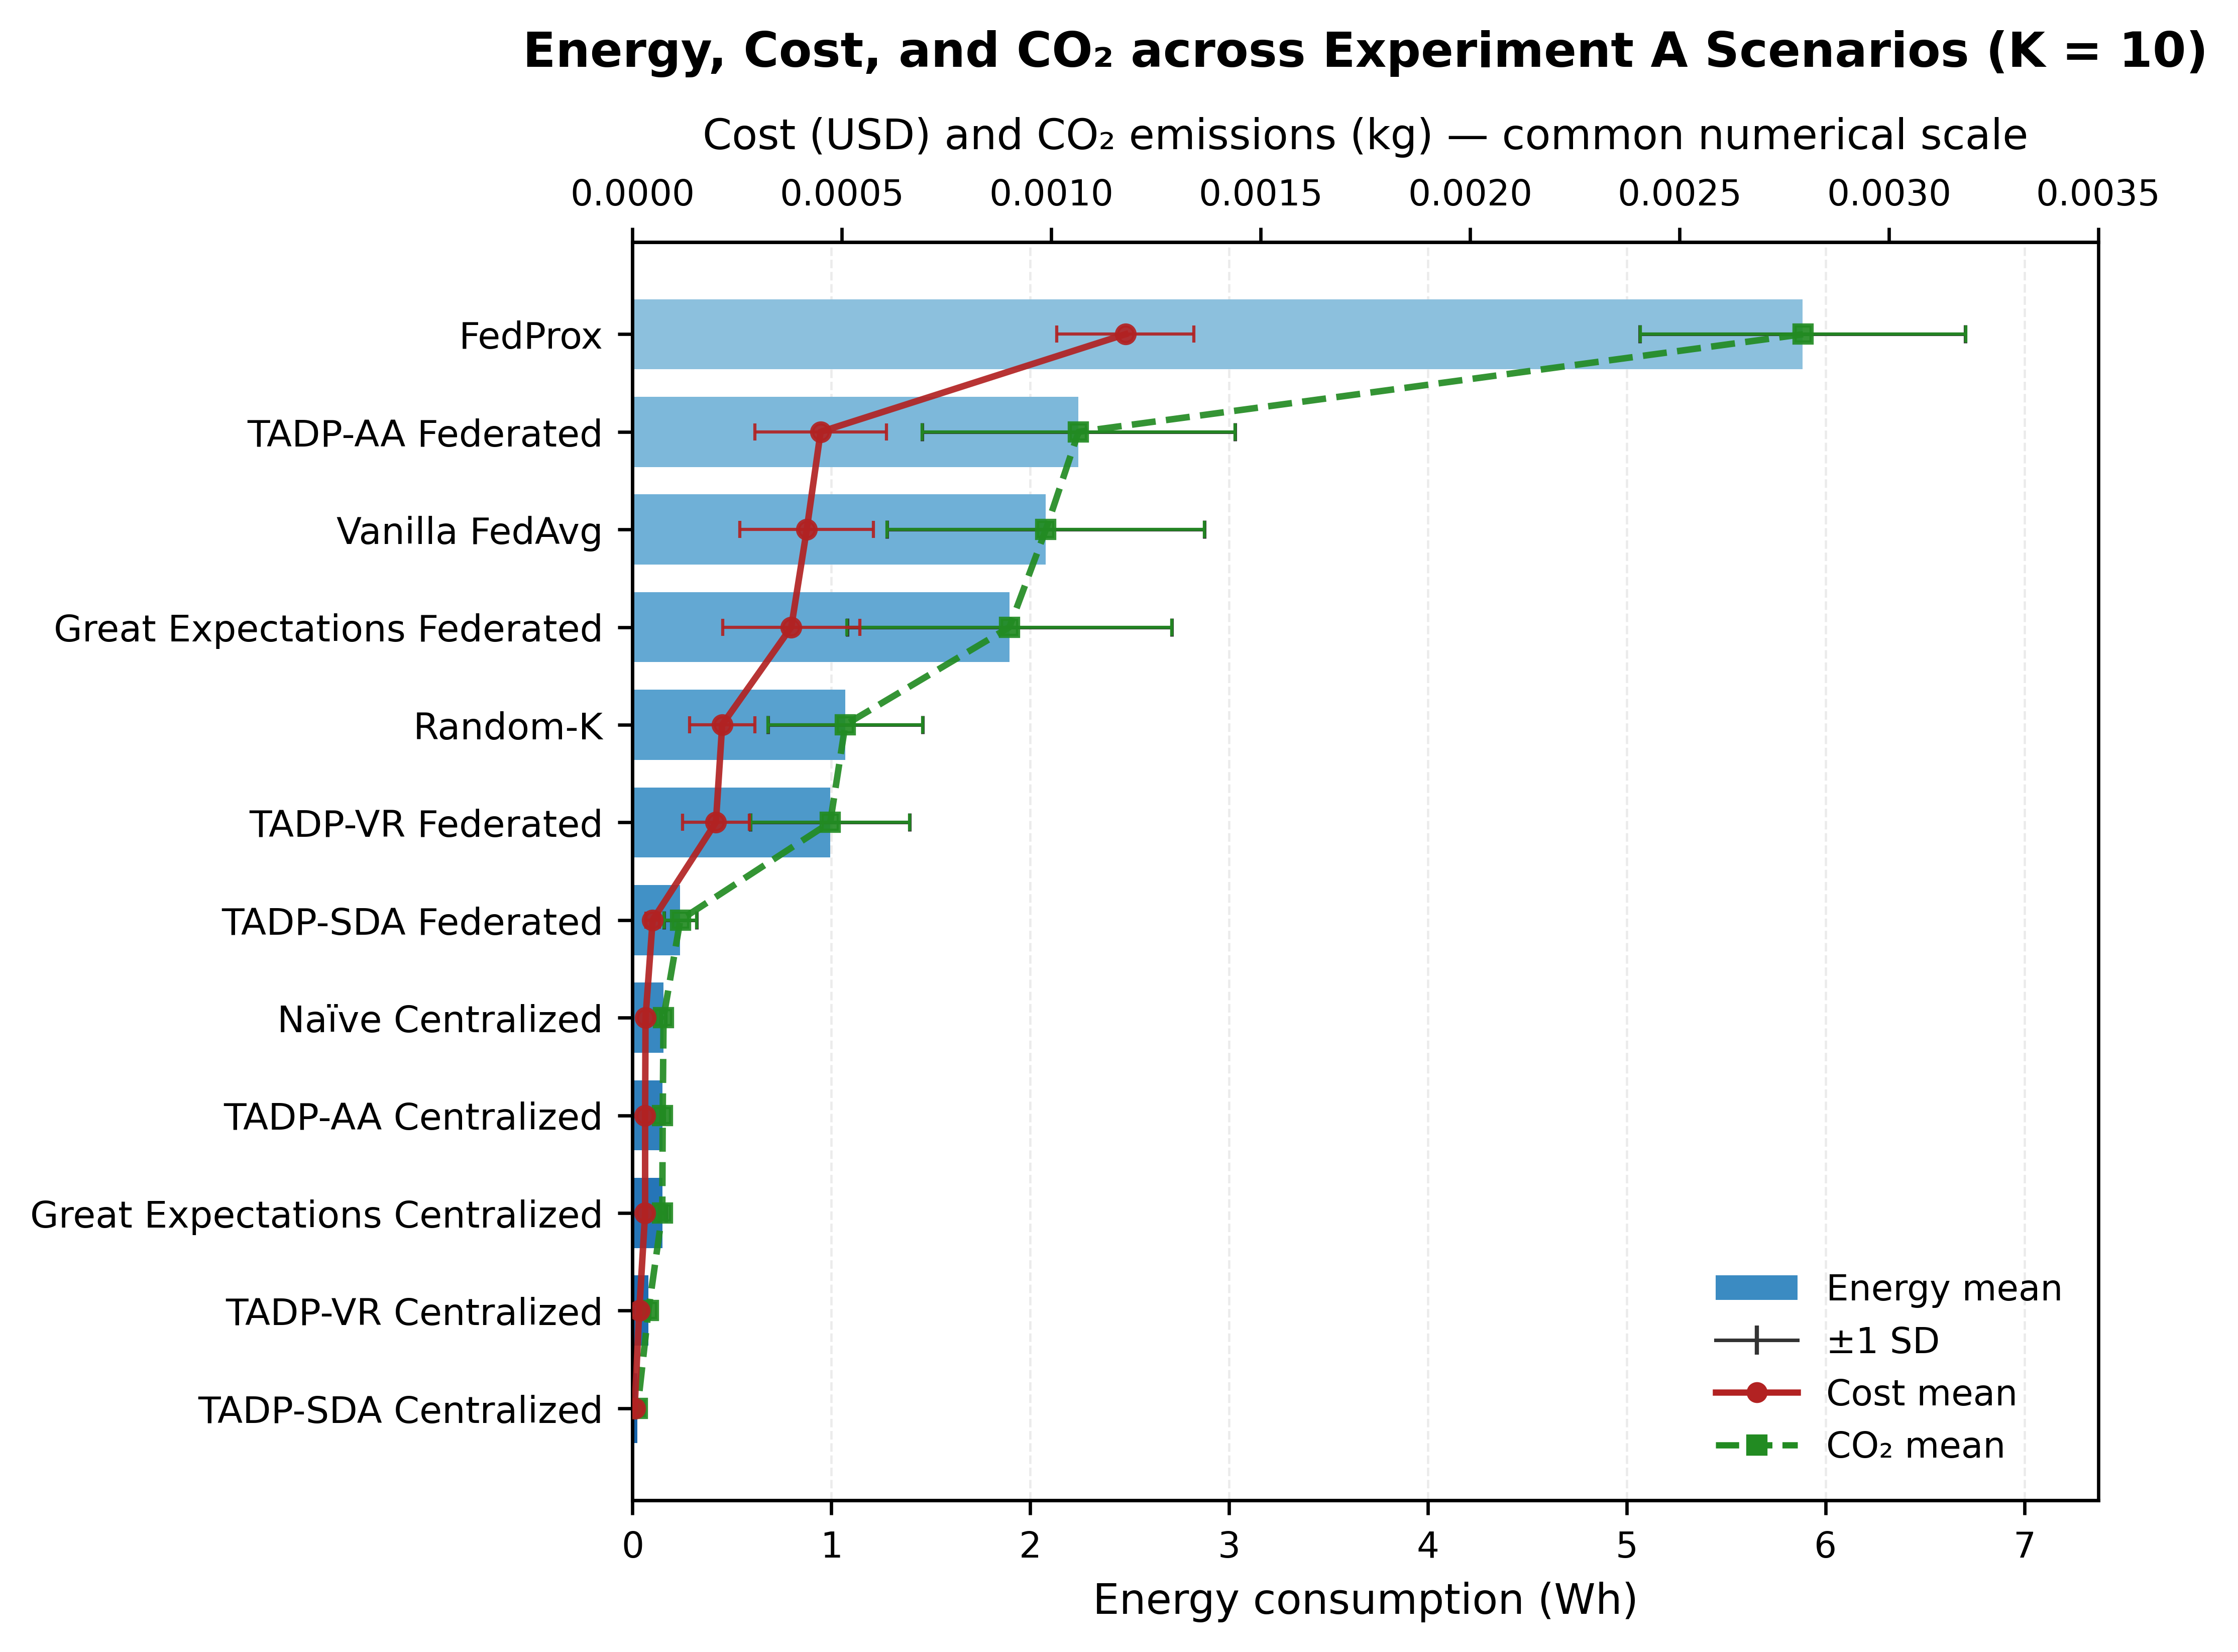

PUBLICATION FIGURE GENERATED
Data: Experiment A, K=10, five-run mean ±1 SD
PNG (600 dpi): /content/ExperimentA_Energy_Cost_CO2_K10_MeanSD_600dpi.png
PDF (vector) : /content/ExperimentA_Energy_Cost_CO2_K10_MeanSD_vector.pdf
SVG (vector) : /content/ExperimentA_Energy_Cost_CO2_K10_MeanSD_vector.svg

Values used:


,Scenario,Energy_Wh,Energy_Wh_SD,Cost_USD,Cost_USD_SD,CO2_kg,CO2_kg_SD
0,FedProx,5.883308,0.818036,0.001177,0.0001636,0.002795,0.000389
1,TADP-AA Federated,2.242822,0.786144,0.000449,0.0001572,0.001065,0.000373
2,Vanilla FedAvg,2.077947,0.798080,0.000416,0.0001596,0.000987,0.000379
3,Great Expectations Federated,1.894954,0.816301,0.000379,0.0001633,0.000900,0.000388
4,Random-K,1.069784,0.390100,0.000214,0.0000780,0.000508,0.000185
5,TADP-VR Federated,0.993326,0.400363,0.000199,0.0000801,0.000472,0.000190
6,TADP-SDA Federated,0.240054,0.081820,0.000048,0.0000164,0.000114,0.000039
7,Naïve Centralized,0.154970,0.010968,0.000031,0.0000022,0.000074,0.000005
8,TADP-AA Centralized,0.151241,0.007290,0.000030,0.0000015,0.000072,0.000003
9,Great Expectations Centralized,0.149906,0.017491,0.000030,0.0000035,0.000071,0.000008


In [3]:
# ======================================================================================
# EXPERIMENT A — PUBLICATION-READY ENERGY / COST / CO2 FIGURE
# K = 10 | 5-run mean ± 1 SD
#
# Source:
# tables/K10_energy_cost_co2_runtime_mean_sd.csv
#
# Figure design:
#   • Energy = horizontal bars, mean ±1 SD
#   • Cost   = circular markers + solid line, mean ±1 SD
#   • CO2    = square markers + dashed line, mean ±1 SD
#   • Energy uses bottom x-axis
#   • Cost and CO2 use a shared numerical top x-axis
#   • 600-dpi PNG + vector PDF
# ======================================================================================

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ======================================================================================
# 1. EXPERIMENT-A FINAL RESULTS
#    Five-run means ± SD retrieved from the final Experiment-A results package
# ======================================================================================

data = [

    ["FedProx",
     5.883308, 0.818036,
     0.001177, 0.0001636072,
     0.002795, 0.000389],

    ["TADP-AA Federated",
     2.242822, 0.786144,
     0.000449, 0.0001572287,
     0.001065, 0.000373],

    ["Vanilla FedAvg",
     2.077947, 0.798080,
     0.000416, 0.0001596160,
     0.000987, 0.000379],

    ["Great Expectations Federated",
     1.894954, 0.816301,
     0.000379, 0.0001632602,
     0.000900, 0.000388],

    ["Random-K",
     1.069784, 0.390100,
     0.000214, 0.0000780200,
     0.000508, 0.000185],

    ["TADP-VR Federated",
     0.993326, 0.400363,
     0.000199, 0.00008007269,
     0.000472, 0.000190],

    ["TADP-SDA Federated",
     0.240054, 0.081820,
     0.000048, 0.00001636391,
     0.000114, 0.000039],

    ["Naïve Centralized",
     0.154970, 0.010968,
     0.000031, 0.000002193631,
     0.000074, 0.000005],

    ["TADP-AA Centralized",
     0.151241, 0.007290,
     0.000030, 0.000001458068,
     0.000072, 0.000003],

    ["Great Expectations Centralized",
     0.149906, 0.017491,
     0.000030, 0.000003498298,
     0.000071, 0.000008],

    ["TADP-VR Centralized",
     0.079703, 0.005834,
     0.000016, 0.000001166808,
     0.000038, 0.000003],

    ["TADP-SDA Centralized",
     0.025038, 0.002898,
     0.000005, 0.0000005796255,
     0.000012, 0.000001],
]


df = pd.DataFrame(
    data,
    columns=[
        "Scenario",
        "Energy_Wh",
        "Energy_Wh_SD",
        "Cost_USD",
        "Cost_USD_SD",
        "CO2_kg",
        "CO2_kg_SD",
    ]
)


# Highest energy first
df = (
    df.sort_values(
        "Energy_Wh",
        ascending=False
    )
    .reset_index(drop=True)
)


# ======================================================================================
# 2. PUBLICATION TYPOGRAPHY / VECTOR FONT SETTINGS
# ======================================================================================

plt.rcParams.update({

    "font.family": "DejaVu Sans",

    "font.size": 9,

    "axes.titlesize": 11.5,

    "axes.labelsize": 10,

    "xtick.labelsize": 8.5,

    "ytick.labelsize": 8.8,

    "legend.fontsize": 8.5,

    # Embed editable TrueType fonts in PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Clean axes
    "axes.linewidth": 0.8,
})


# ======================================================================================
# 3. HELPERS
# ======================================================================================

def round_up(x, step):

    if x <= 0:
        return step

    return (
        math.ceil(x / step)
        * step
    )


def choose_nice_step(max_value, target_intervals=7):

    rough = max_value / target_intervals

    magnitude = 10 ** math.floor(
        math.log10(rough)
    )

    normalized = rough / magnitude

    if normalized <= 1:
        nice = 1

    elif normalized <= 2:
        nice = 2

    elif normalized <= 2.5:
        nice = 2.5

    elif normalized <= 5:
        nice = 5

    else:
        nice = 10

    return nice * magnitude


# ======================================================================================
# 4. Y-AXIS GEOMETRY
# ======================================================================================

bar_height = 0.56
bar_gap = 0.22

y = (
    np.arange(len(df))
    * (bar_height + bar_gap)
)


# ======================================================================================
# 5. FIGURE
# ======================================================================================

# ~180 mm wide, appropriate for a two-column journal figure
fig, ax_energy = plt.subplots(
    figsize=(7.6, 5.8),
    dpi=600
)


# ======================================================================================
# 6. ENERGY — MEAN ± 1 SD
# ======================================================================================

bar_colors = plt.cm.Blues(
    np.linspace(
        0.42,
        0.80,
        len(df)
    )
)


ax_energy.barh(
    y,
    df["Energy_Wh"],
    height=bar_height,
    color=bar_colors,
    edgecolor="none",
    zorder=2
)


# Error bars kept deliberately thin
ax_energy.errorbar(
    df["Energy_Wh"],
    y,
    xerr=df["Energy_Wh_SD"],
    fmt="none",
    ecolor="0.20",
    elinewidth=0.85,
    capsize=2.2,
    capthick=0.85,
    zorder=4
)


ax_energy.set_yticks(y)

ax_energy.set_yticklabels(
    df["Scenario"]
)

ax_energy.invert_yaxis()


ax_energy.set_xlabel(
    "Energy consumption (Wh)"
)


# Include SD in energy-axis limit
energy_upper = (
    df["Energy_Wh"]
    + df["Energy_Wh_SD"]
).max()


ax_energy.set_xlim(
    0,
    energy_upper * 1.10
)


# Very light grid
ax_energy.grid(
    axis="x",
    linestyle="--",
    linewidth=0.55,
    alpha=0.25,
    zorder=0
)


# Clean frame
ax_energy.spines["right"].set_visible(False)


# ======================================================================================
# 7. TOP AXIS — COST AND CO2
# ======================================================================================

ax_top = ax_energy.twiny()


top_upper = max(

    (
        df["Cost_USD"]
        + df["Cost_USD_SD"]
    ).max(),

    (
        df["CO2_kg"]
        + df["CO2_kg_SD"]
    ).max()
)


top_step = choose_nice_step(
    top_upper,
    target_intervals=7
)


top_xlim = round_up(
    top_upper * 1.06,
    top_step
)


ax_top.set_xlim(
    0,
    top_xlim
)


ax_top.set_xlabel(
    "Cost (USD) and CO₂ emissions (kg) — common numerical scale",
    labelpad=7
)


top_ticks = np.arange(
    0,
    top_xlim + top_step / 2,
    top_step
)


ax_top.set_xticks(
    top_ticks
)


# Choose precision automatically
if top_xlim < 0.001:

    decimals = 5

elif top_xlim < 0.01:

    decimals = 4

else:

    decimals = 3


ax_top.set_xticklabels(
    [
        f"{v:.{decimals}f}"
        for v in top_ticks
    ]
)


# ======================================================================================
# 8. COST — MEAN ± 1 SD
# ======================================================================================

ax_top.errorbar(
    df["Cost_USD"],
    y,
    xerr=df["Cost_USD_SD"],

    fmt="o-",

    linewidth=1.55,
    markersize=4.2,

    elinewidth=0.75,
    capsize=2.0,
    capthick=0.75,

    color="firebrick",

    markerfacecolor="firebrick",
    markeredgecolor="firebrick",

    alpha=0.92,

    zorder=6,

    label="Cost"
)


# ======================================================================================
# 9. CO2 — MEAN ± 1 SD
# ======================================================================================

ax_top.errorbar(
    df["CO2_kg"],
    y,
    xerr=df["CO2_kg_SD"],

    fmt="s--",

    linewidth=1.55,
    markersize=4.0,

    elinewidth=0.75,
    capsize=2.0,
    capthick=0.75,

    color="forestgreen",

    markerfacecolor="forestgreen",
    markeredgecolor="forestgreen",

    alpha=0.92,

    zorder=5,

    label="CO₂"
)


# ======================================================================================
# 10. TITLE
# ======================================================================================

ax_energy.set_title(
    "Energy, Cost, and CO₂ across Experiment A Scenarios (K = 10)",
    pad=12,
    fontweight="semibold"
)


# ======================================================================================
# 11. COMPACT PUBLICATION LEGEND
# ======================================================================================

legend_handles = [

    Patch(
        facecolor=plt.cm.Blues(0.65),
        edgecolor="none",
        label="Energy mean"
    ),

    Line2D(
        [0],
        [0],
        color="0.20",
        linewidth=0.85,
        marker="|",
        markersize=7,
        label="±1 SD"
    ),

    Line2D(
        [0],
        [0],
        color="firebrick",
        marker="o",
        linewidth=1.5,
        markersize=4,
        label="Cost mean"
    ),

    Line2D(
        [0],
        [0],
        color="forestgreen",
        linestyle="--",
        marker="s",
        linewidth=1.5,
        markersize=4,
        label="CO₂ mean"
    ),
]


ax_energy.legend(
    handles=legend_handles,
    loc="lower right",
    frameon=False,
    handlelength=2.3,
    borderaxespad=0.6
)


# ======================================================================================
# 12. FINAL LAYOUT
# ======================================================================================

fig.subplots_adjust(
    left=0.34,
    right=0.98,
    bottom=0.10,
    top=0.82
)


# ======================================================================================
# 13. SAVE — 600 DPI + VECTOR PDF
# ======================================================================================

OUT_DIR = (
    "/content"
    if os.path.isdir("/content")
    else "."
)


png_path = os.path.join(
    OUT_DIR,
    "ExperimentA_Energy_Cost_CO2_K10_MeanSD_600dpi.png"
)


pdf_path = os.path.join(
    OUT_DIR,
    "ExperimentA_Energy_Cost_CO2_K10_MeanSD_vector.pdf"
)


svg_path = os.path.join(
    OUT_DIR,
    "ExperimentA_Energy_Cost_CO2_K10_MeanSD_vector.svg"
)


plt.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)


plt.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)


plt.savefig(
    svg_path,
    bbox_inches="tight",
    facecolor="white"
)


plt.show()


# ======================================================================================
# 14. AUDIT OUTPUT
# ======================================================================================

print("=" * 88)

print(
    "PUBLICATION FIGURE GENERATED"
)

print("=" * 88)

print(
    "Data: Experiment A, K=10, five-run mean ±1 SD"
)

print(
    f"PNG (600 dpi): {png_path}"
)

print(
    f"PDF (vector) : {pdf_path}"
)

print(
    f"SVG (vector) : {svg_path}"
)


print(
    "\nValues used:"
)


display(
    df[
        [
            "Scenario",
            "Energy_Wh",
            "Energy_Wh_SD",
            "Cost_USD",
            "Cost_USD_SD",
            "CO2_kg",
            "CO2_kg_SD",
        ]
    ].style.format({

        "Energy_Wh":
            "{:.6f}",

        "Energy_Wh_SD":
            "{:.6f}",

        "Cost_USD":
            "{:.6f}",

        "Cost_USD_SD":
            "{:.7f}",

        "CO2_kg":
            "{:.6f}",

        "CO2_kg_SD":
            "{:.6f}",
    })
)